In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Read data
pd.set_option('display.max_columns', None)
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)

#Subset my interested columns
df = data[['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'country_txt', 'region_txt', 'crit1', 'crit2', 'crit3', 'attacktype1_txt', 
           'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targtype2_txt', 'targtype3_txt', 'claimed', 'weaptype1_txt', 'weaptype2_txt',
           'weaptype3_txt', 'nkill', 'nwound', 'property', 'propextent_txt', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']]



C:\Users\alist\AppData\Local\Temp\ipykernel_27380\3746818610.py:7: DtypeWarning: Columns (4,31,33,54,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


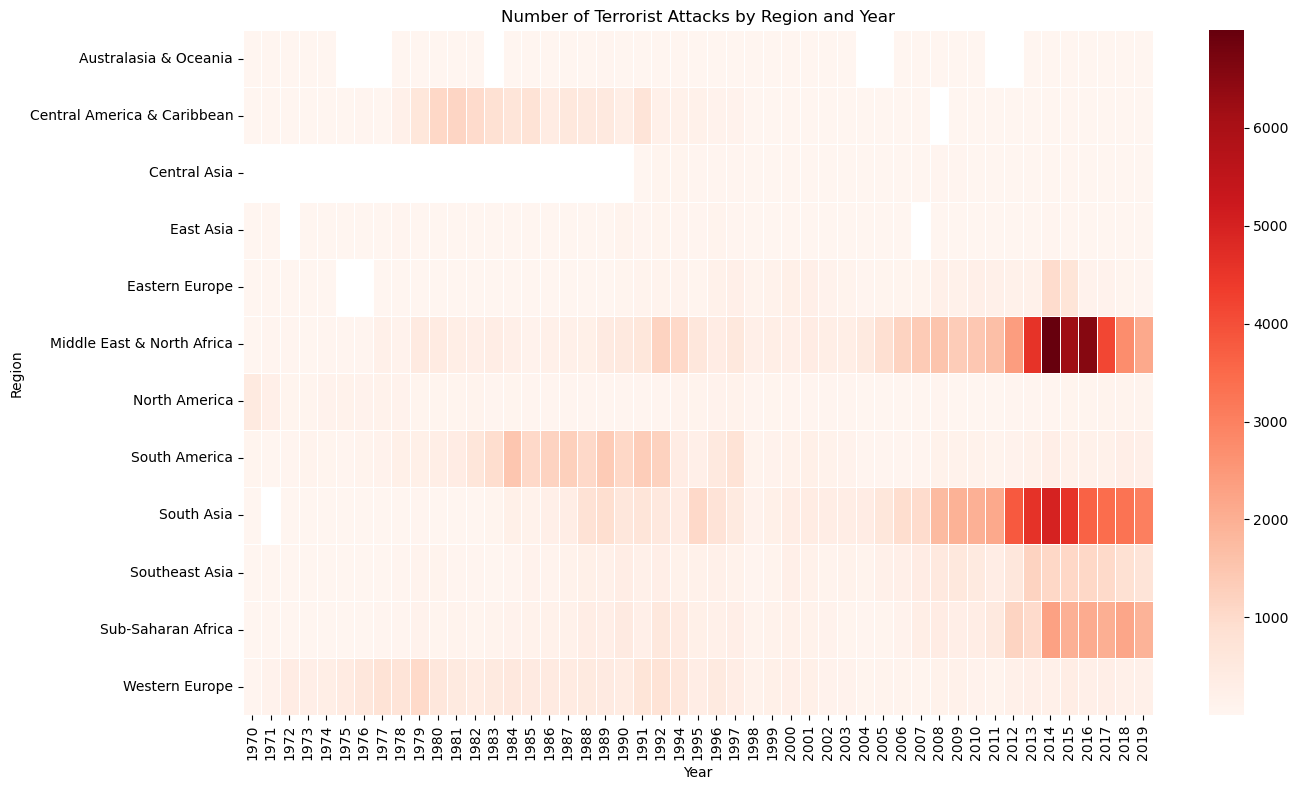

In [48]:
import numpy as np
#Build a heatmap for number of attacks by region
attacks = (df.groupby(['region_txt', 'iyear']).size().reset_index(name="attack_count"))

heatmap_data = attacks.pivot(
    index="region_txt",
    columns="iyear",
    values="attack_count"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Number of Terrorist Attacks by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

<Axes: xlabel='iyear', ylabel='region_txt'>

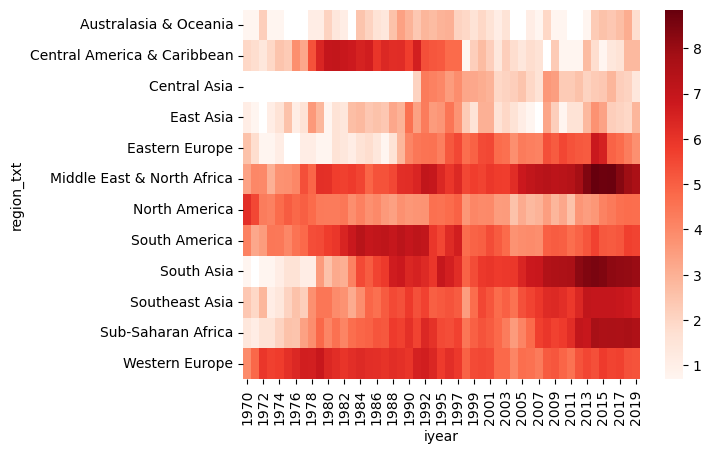

In [49]:
#Because the number of attacks in the middle east and north africa (Specically from 2013-2017)
#cause heavy bias in the graph I tried a log scaled graph so that comparing the other regions/times was easier.
sns.heatmap(
    np.log1p(heatmap_data),
    cmap="Reds"
)

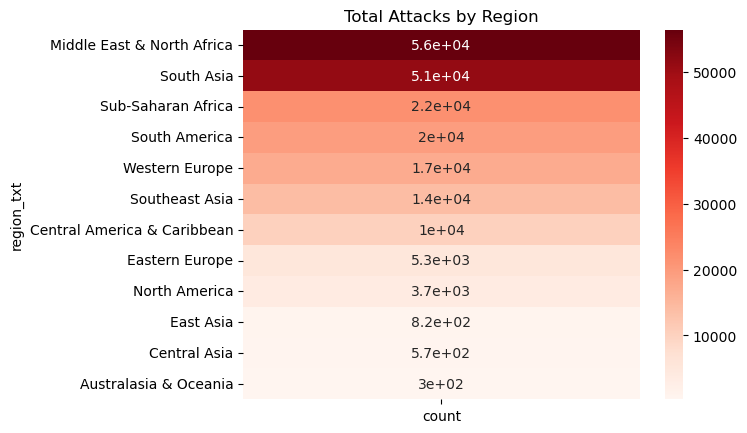

In [53]:
#Same heatmap concept, just without separating by year
region_counts = df["region_txt"].value_counts()

sns.heatmap(
    region_counts.to_frame(),
    annot=True,
    cmap="Reds"
)

plt.title("Total Attacks by Region")
plt.show()

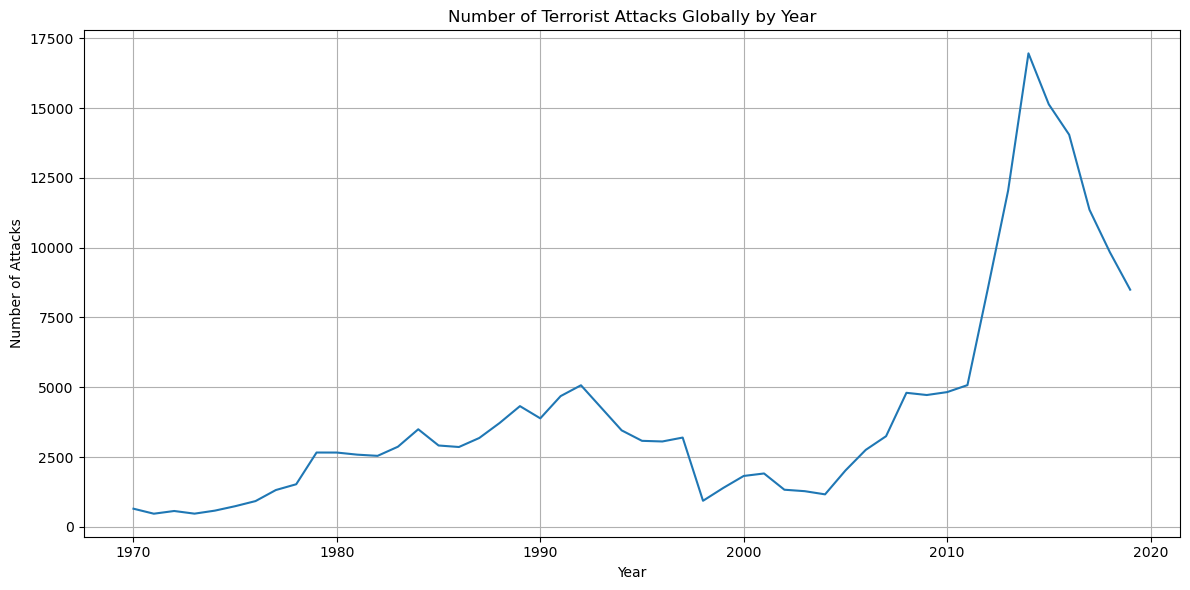

In [55]:
#Plot a line graph to show number of attacks per year.
attacks_per_year = (
    df.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

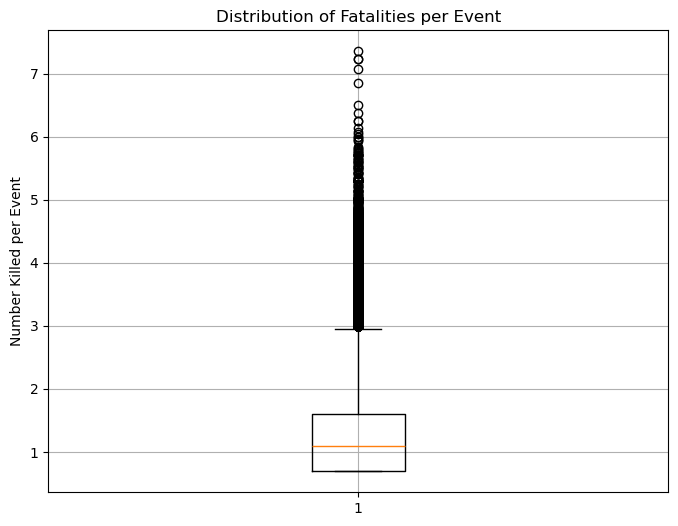

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean fatalities data
killed = df["nkill"].dropna()

# Optional: remove negative values (rare but safe practice)
killed = killed[killed >= 0]

killed.head(5)

log_killed = np.log1p(killed)

plt.figure(figsize=(8, 6))

plt.boxplot(log_killed)

plt.title("Distribution of Fatalities per Event")
plt.ylabel("Number Killed per Event")

plt.grid(True)

plt.show()

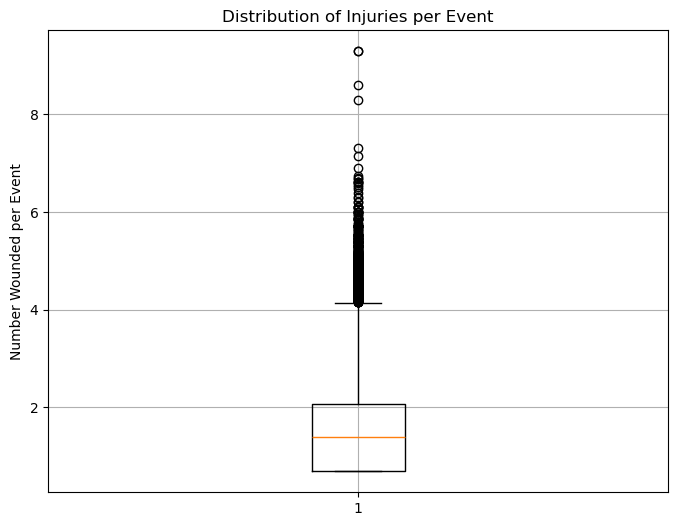

In [68]:
# Clean injury data
wounded = df["nwound"].dropna()

# Remove negative values
wounded = wounded[wounded >= 0]
log_wounded = np.log1p(wounded)

plt.figure(figsize=(8, 6))

plt.boxplot(log_wounded)

plt.title("Distribution of Injuries per Event")
plt.ylabel("Number Wounded per Event")

plt.grid(True)

plt.show()